# Etapa 2 — Modelagem e Avaliação da MLP

Notebook experimental para a  construção da MLP em PyTorch, treino com batching e early stopping, comparação com baselines, análise de custo e registro final no MLflow.

## Objetivos

- Construir e treinar uma MLP em PyTorch com batching e early stopping.
- Comparar a MLP com baselines sklearn em métricas técnicas e econômicas.
- Reforçar validade experimental com estratificação e rastreabilidade de runs.
- Registrar modelo final e artefatos de avaliação no MLflow/Model Registry.

## 1. Imports, paths, seeds e MLflow

In [52]:
from __future__ import annotations

import copy
import hashlib
import json
import logging
import math
import os
import random
import tempfile
from pathlib import Path
from typing import Any

import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
from mlflow.utils.logging_utils import disable_logging, enable_logging
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "etapa2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.20
TARGET_COLUMN = "target"
EXPERIMENT_NAME = "telco-churn-mlp-notebooks"
BASELINE_EXPERIMENT_NAME = "telco-churn-etapa-1-baselines"
MLFLOW_DATASET_EXPERIMENT_NAME = "telco-churn-dataset"
# Single SQLite backend shared with Etapa 1 baselines.
MLFLOW_DB_PATH = PROJECT_ROOT / "mlflow.db"
MLFLOW_TRACKING_URI = f"sqlite:///{MLFLOW_DB_PATH.resolve().as_posix()}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

logging.getLogger("mlflow.pytorch").setLevel(logging.ERROR)
logging.getLogger("mlflow.sklearn").setLevel(logging.ERROR)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_published_processed_dataset(
    *,
    tracking_uri: str,
    dataset_experiment: str,
) -> tuple[pd.DataFrame, dict, str]:
    """Última publicação do notebook 01 no MLflow, ou run fixada em DATASET_MLFLOW_RUN_ID."""
    mlflow.set_tracking_uri(tracking_uri)
    client = MlflowClient(tracking_uri=tracking_uri)
    run_override = (os.environ.get("DATASET_MLFLOW_RUN_ID") or "").strip()
    if run_override:
        run_id = run_override
    else:
        exp = client.get_experiment_by_name(dataset_experiment)
        if exp is None:
            raise RuntimeError(
                "Experimento de dataset ausente. Execute o notebook 01 até publicar "
                f"({dataset_experiment!r})."
            )
        runs = client.search_runs(
            experiment_ids=[exp.experiment_id],
            filter_string="tags.dataset_kind = 'telco_churn_model_ready'",
            order_by=["attributes.start_time DESC"],
            max_results=1,
        )
        if not runs:
            raise RuntimeError(
                "Nenhum dataset no MLflow. Complete o notebook 01 ou defina DATASET_MLFLOW_RUN_ID."
            )
        run_id = runs[0].info.run_id

    tmpdir = tempfile.mkdtemp(prefix="telco_dataset_")
    local_dataset_dir = Path(client.download_artifacts(run_id, "dataset", tmpdir))
    dataset_csv = local_dataset_dir / "telco_churn_model_ready.csv"
    manifest_json = local_dataset_dir / "telco_churn_model_ready_manifest.json"
    if not dataset_csv.is_file():
        raise FileNotFoundError(f"CSV ausente após download MLflow: {dataset_csv}")
    manifest_local = json.loads(manifest_json.read_text(encoding="utf-8"))
    actual_hash = sha256_file(dataset_csv)
    expected_hash = manifest_local["output_sha256"]
    if actual_hash != expected_hash:
        raise ValueError(f"Hash do dataset divergente: {actual_hash} != {expected_hash}")
    return pd.read_csv(dataset_csv), manifest_local, run_id



def set_seeds(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = False


set_seeds(RANDOM_SEED)
print(f"project_root={PROJECT_ROOT}")
print(f"device={DEVICE}")
print(f"mlflow_tracking_uri={mlflow.get_tracking_uri()}")


project_root=/Users/crisley/Documents/postech-ml-challenge-fase-1
device=cpu
mlflow_tracking_uri=sqlite:////Users/crisley/Documents/postech-ml-challenge-fase-1/mlflow.db


## 2. Carga dos dados, target, leakage e split

Dados a partir do MLflow (`telco-churn-dataset`, última run com tag `dataset_kind`, ou `DATASET_MLFLOW_RUN_ID`). Validação SHA256 igual ao notebook 02.

In [53]:
df, manifest, DATASET_SOURCE_RUN_ID = load_published_processed_dataset(
    tracking_uri=MLFLOW_TRACKING_URI,
    dataset_experiment=MLFLOW_DATASET_EXPERIMENT_NAME,
)
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)
actual_hash = manifest["output_sha256"]
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

x_train_full, x_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED,
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=VAL_SIZE,
    stratify=y_train_full,
    random_state=RANDOM_SEED,
)
x_test_raw = x_test.copy()
y_test_array = y_test.to_numpy()

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(x_train), "churn_rate": y_train.mean()},
        {"split": "validation", "rows": len(x_val), "churn_rate": y_val.mean()},
        {"split": "test", "rows": len(x_test), "churn_rate": y_test.mean()},
    ]
)
print(f"dataset_mlflow_run_id={DATASET_SOURCE_RUN_ID}")
print(f"dataset_sha256={actual_hash}")
print(f"dataset_shape={df.shape}")
print(f"feature_shape={X.shape}")
split_summary.style.format({"churn_rate": "{:.2%}"})


dataset_mlflow_run_id=37456a084b424bedbecda23b4d3123bd
dataset_sha256=e2b44e32aec0bc015c923deec5c00fddfdfaa0f6776efb0c9a22eaca7f4e3b74
dataset_shape=(7043, 42)
feature_shape=(7043, 41)


,split,rows,churn_rate
0,train,4507,26.54%
1,validation,1127,26.53%
2,test,1409,26.54%


## 3. Pré-processamento e DataLoaders

Imputa e escala variáveis numéricas, imputa e aplica one-hot nas categóricas. O `fit` do pré-processador acontece apenas no treino.

In [54]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(x: pd.DataFrame) -> ColumnTransformer:
    numeric_features = x.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = x.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_one_hot_encoder()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )


def as_float_tensor(values: Any) -> torch.Tensor:
    if hasattr(values, "toarray"):
        values = values.toarray()
    return torch.tensor(values, dtype=torch.float32)


preprocessor = build_preprocessor(x_train)
x_train_processed = preprocessor.fit_transform(x_train)
x_val_processed = preprocessor.transform(x_val)
x_test_processed = preprocessor.transform(x_test)

x_train_tensor = as_float_tensor(x_train_processed)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
x_val_tensor = as_float_tensor(x_val_processed)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).view(-1, 1)
x_test_tensor = as_float_tensor(x_test_processed)
INPUT_DIM = x_train_tensor.shape[1]


def make_loaders(batch_size: int) -> tuple[DataLoader, DataLoader]:
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
    )


numeric_features = x_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = x_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()
try:
    feature_names = preprocessor.get_feature_names_out().tolist()
except Exception:
    feature_names = [f"feature_{i}" for i in range(INPUT_DIM)]

feature_summary = pd.DataFrame(
    [
        {"feature_group": "numeric_original", "count": len(numeric_features)},
        {"feature_group": "categorical_original", "count": len(categorical_features)},
        {"feature_group": "processed_input_dim", "count": INPUT_DIM},
    ]
)
feature_summary

,feature_group,count
0,numeric_original,17
1,categorical_original,24
2,processed_input_dim,2791


## 4. Arquitetura da MLP

A saída é um logit, não uma probabilidade. 

A sigmoid é aplicada apenas na avaliação, porque `BCEWithLogitsLoss` combina sigmoid + BCE de forma numericamente mais estável.

```mermaid
flowchart LR
    inputLayer[Input features] --> hidden1[Linear inputDim to hiddenDim]
    hidden1 --> relu1[ReLU]
    relu1 --> dropout1[Dropout]
    dropout1 --> hidden2[Linear hiddenDim to halfHidden]
    hidden2 --> relu2[ReLU]
    relu2 --> dropout2[Dropout]
    dropout2 --> outputLayer[Linear halfHidden to 1 logit]
```

In [55]:
class TelcoMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, dropout_rate: float = 0.2):
        super().__init__()
        half_hidden = max(hidden_dim // 2, 1)
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, half_hidden),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(half_hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


def parameter_table(model: nn.Module) -> pd.DataFrame:
    rows = []
    total = 0
    for name, parameter in model.named_parameters():
        n_params = int(parameter.numel())
        rows.append({"parameter": name, "shape": tuple(parameter.shape), "n_params": n_params})
        total += n_params
    rows.append({"parameter": "TOTAL", "shape": "", "n_params": total})
    return pd.DataFrame(rows)


example_model = TelcoMLP(INPUT_DIM, hidden_dim=64, dropout_rate=0.2)
parameter_table(example_model)

,parameter,shape,n_params
0,network.0.weight,"(64, 2791)",178624
1,network.0.bias,"(64,)",64
2,network.3.weight,"(32, 64)",2048
3,network.3.bias,"(32,)",32
4,network.6.weight,"(1, 32)",32
5,network.6.bias,"(1,)",1
6,TOTAL,,180801


## 5. Loop de treinamento e early stopping

O loop mantém histórico por época para análise de curva de aprendizado. 

O early stopping restaura os melhores pesos observados no monitor escolhido.

In [56]:
def safe_roc_auc(y_true: np.ndarray, probabilities: np.ndarray) -> float:
    try:
        return float(roc_auc_score(y_true, probabilities))
    except ValueError:
        return float("nan")


def safe_pr_auc(y_true: np.ndarray, probabilities: np.ndarray) -> float:
    try:
        return float(average_precision_score(y_true, probabilities))
    except ValueError:
        return float("nan")


def evaluate_binary(
    y_true: np.ndarray | pd.Series,
    probabilities: np.ndarray,
    threshold: float = 0.5,
) -> dict[str, float]:
    y_true_array = np.asarray(y_true)
    predictions = (probabilities >= threshold).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true_array, predictions)),
        "precision": float(precision_score(y_true_array, predictions, zero_division=0)),
        "recall": float(recall_score(y_true_array, predictions, zero_division=0)),
        "f1": float(f1_score(y_true_array, predictions, zero_division=0)),
        "roc_auc": safe_roc_auc(y_true_array, probabilities),
        "pr_auc": safe_pr_auc(y_true_array, probabilities),
    }


def finite_metrics(metrics: dict[str, float]) -> dict[str, float]:
    return {key: value for key, value in metrics.items() if math.isfinite(value)}


class EarlyStopping:
    def __init__(
        self,
        patience: int,
        min_delta: float,
        mode: str = "min",
        restore_best_weights: bool = True,
    ) -> None:
        if patience < 1:
            raise ValueError("patience must be >= 1")
        if mode not in {"min", "max"}:
            raise ValueError("mode must be 'min' or 'max'")
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.best_score: float | None = None
        self.best_epoch: int | None = None
        self.wait_count = 0
        self.early_stopped = False
        self._best_state_dict: dict[str, torch.Tensor] | None = None

    def _is_improvement(self, metric_value: float) -> bool:
        if self.best_score is None:
            return True
        if self.mode == "min":
            return metric_value < self.best_score - self.min_delta
        return metric_value > self.best_score + self.min_delta

    def step(self, metric_value: float, model: nn.Module, epoch: int) -> bool:
        if math.isfinite(metric_value) and self._is_improvement(metric_value):
            self.best_score = metric_value
            self.best_epoch = epoch
            self.wait_count = 0
            if self.restore_best_weights:
                self._best_state_dict = copy.deepcopy(model.state_dict())
            return False
        self.wait_count += 1
        self.early_stopped = self.wait_count >= self.patience
        return self.early_stopped

    def restore(self, model: nn.Module) -> None:
        if self.restore_best_weights and self._best_state_dict is not None:
            model.load_state_dict(self._best_state_dict)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> float:
    model.train()
    running_loss = 0.0
    sample_count = 0
    for batch_features, batch_targets in loader:
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)
        optimizer.zero_grad()
        logits = model(batch_features)
        loss = criterion(logits, batch_targets)
        loss.backward()
        optimizer.step()
        batch_size = batch_features.size(0)
        running_loss += float(loss.item()) * batch_size
        sample_count += batch_size
    return running_loss / sample_count


def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    running_loss = 0.0
    sample_count = 0
    logits_batches: list[torch.Tensor] = []
    target_batches: list[torch.Tensor] = []
    with torch.no_grad():
        for batch_features, batch_targets in loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            logits = model(batch_features)
            loss = criterion(logits, batch_targets)
            batch_size = batch_features.size(0)
            running_loss += float(loss.item()) * batch_size
            sample_count += batch_size
            logits_batches.append(logits.detach().cpu())
            target_batches.append(batch_targets.detach().cpu())
    logits = torch.cat(logits_batches).reshape(-1)
    targets = torch.cat(target_batches).reshape(-1).numpy()
    probabilities = torch.sigmoid(logits).numpy()
    metrics = evaluate_binary(targets, probabilities, threshold=0.5)
    return {
        "val_loss": running_loss / sample_count,
        "val_accuracy": metrics["accuracy"],
        "val_precision": metrics["precision"],
        "val_recall": metrics["recall"],
        "val_f1": metrics["f1"],
        "val_roc_auc": metrics["roc_auc"],
        "val_pr_auc": metrics["pr_auc"],
    }


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    *,
    epochs: int,
    early_stopping: EarlyStopping,
    monitor: str,
    device: torch.device,
    mlflow_logger: Any | None = None,
) -> pd.DataFrame:
    history: list[dict[str, float | int]] = []
    model.to(device)
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)
        epoch_record = {"epoch": epoch, "train_loss": train_loss, **val_metrics}
        history.append(epoch_record)
        if mlflow_logger is not None:
            mlflow_logger.log_metrics(
                finite_metrics({k: float(v) for k, v in epoch_record.items() if k != "epoch"}),
                step=epoch,
            )
        if early_stopping.step(float(val_metrics[monitor]), model, epoch):
            break
    early_stopping.restore(model)
    return pd.DataFrame(history)


def predict_mlp_probabilities(model: nn.Module, features_tensor: torch.Tensor, device: torch.device = DEVICE) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        logits = model(features_tensor.to(device)).detach().cpu().reshape(-1)
    return torch.sigmoid(logits).numpy()

## 6. Treino da MLP

Configuração inicial para servir como ponto de comparação: `hidden_dim=64`, `dropout=0.2`, `lr=1e-3`, `batch_size=32`, `epochs=100`, `patience=10`.

In [57]:
comparison_rows: list[dict[str, Any]] = []
model_probabilities: dict[str, np.ndarray] = {}
sklearn_models: dict[str, Pipeline] = {}

CANONICAL_CONFIG = {
    "hidden_dim": 64,
    "dropout_rate": 0.2,
    "learning_rate": 1e-3,
    "batch_size": 32,
    "epochs": 100,
    "patience": 10,
    "min_delta": 1e-4,
    "monitor": "val_loss",
}

set_seeds(RANDOM_SEED)
train_loader, val_loader = make_loaders(CANONICAL_CONFIG["batch_size"])
mlp_canonical = TelcoMLP(
    input_dim=INPUT_DIM,
    hidden_dim=CANONICAL_CONFIG["hidden_dim"],
    dropout_rate=CANONICAL_CONFIG["dropout_rate"],
)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp_canonical.parameters(), lr=CANONICAL_CONFIG["learning_rate"])
early_stopping = EarlyStopping(
    patience=CANONICAL_CONFIG["patience"],
    min_delta=CANONICAL_CONFIG["min_delta"],
    mode="min",
)

with mlflow.start_run(run_name="mlp-canonical") as canonical_run:
    mlflow.set_tag("dataset.mlflow_run_id", DATASET_SOURCE_RUN_ID)
    mlflow.log_params({**CANONICAL_CONFIG, "input_dim": INPUT_DIM, "random_seed": RANDOM_SEED, "device": str(DEVICE)})
    history_canonical = fit(
        model=mlp_canonical,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=CANONICAL_CONFIG["epochs"],
        early_stopping=early_stopping,
        monitor=CANONICAL_CONFIG["monitor"],
        device=DEVICE,
        mlflow_logger=mlflow,
    )
    mlflow.log_metrics({
        "epochs_trained": int(len(history_canonical)),
        "best_epoch": int(early_stopping.best_epoch or 0),
        "best_score": float(early_stopping.best_score or 0.0),
    })
    history_path = OUTPUT_DIR / "mlp_canonical_history.json"
    history_canonical.to_json(history_path, orient="records", indent=2)
    mlflow.log_artifact(str(history_path), artifact_path="training")

canonical_run_id = canonical_run.info.run_id
history_canonical.tail()

,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
9,10,0.022494,0.148176,0.954747,0.946043,0.879599,0.911612,0.987903,0.974695
10,11,0.018263,0.151814,0.955634,0.943060,0.886288,0.913793,0.988306,0.975640
11,12,0.013925,0.166428,0.950311,0.929329,0.879599,0.903780,0.986634,0.972294
12,13,0.016515,0.167175,0.956522,0.949640,0.882943,0.915078,0.987874,0.974728
13,14,0.013202,0.166073,0.950311,0.900990,0.913043,0.906977,0.987967,0.974919


## 7. Avaliação do MLP

Métricas finais no test set, matriz de confusão, curvas ROC/PR e curvas de aprendizado.

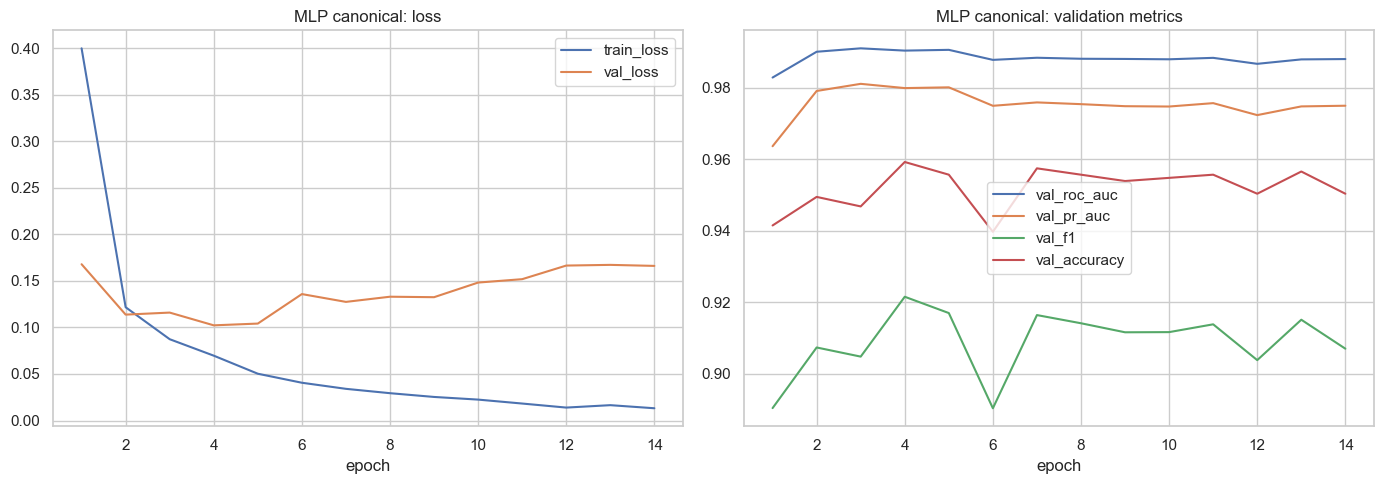

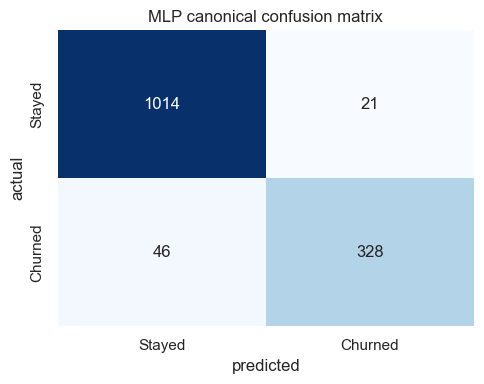

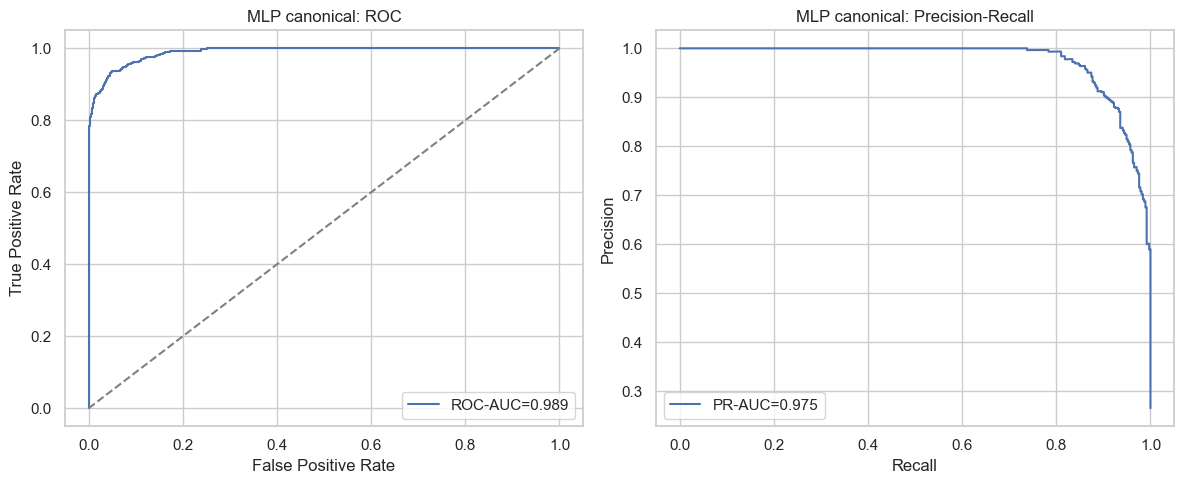

,accuracy,precision,recall,f1,roc_auc,pr_auc
MLP-canonical,0.9524,0.9398,0.8770,0.9073,0.9891,0.9754


In [58]:
def save_learning_curves(history: pd.DataFrame, output_path: Path, title: str) -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
    axes[0].plot(history["epoch"], history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    for metric in ["val_roc_auc", "val_pr_auc", "val_f1", "val_accuracy"]:
        axes[1].plot(history["epoch"], history[metric], label=metric)
    axes[1].set_title(f"{title}: validation metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return output_path


def save_confusion_heatmap(y_true: np.ndarray, probabilities: np.ndarray, threshold: float, output_path: Path, title: str) -> Path:
    predictions = (probabilities >= threshold).astype(int)
    matrix = confusion_matrix(y_true, predictions)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    ax.set_xticklabels(["Stayed", "Churned"])
    ax.set_yticklabels(["Stayed", "Churned"])
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return output_path


def save_roc_pr_curves(y_true: np.ndarray, probabilities: np.ndarray, output_path: Path, title: str) -> Path:
    fpr, tpr, _ = roc_curve(y_true, probabilities)
    precision, recall, _ = precision_recall_curve(y_true, probabilities)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(y_true, probabilities):.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title(f"{title}: ROC")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()
    axes[1].plot(recall, precision, label=f"PR-AUC={average_precision_score(y_true, probabilities):.3f}")
    axes[1].set_title(f"{title}: Precision-Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return output_path


mlp_canonical_probabilities = predict_mlp_probabilities(mlp_canonical, x_test_tensor)
metrics_canonical = evaluate_binary(y_test_array, mlp_canonical_probabilities, threshold=0.5)
model_probabilities["MLP-canonical"] = mlp_canonical_probabilities
comparison_rows.append({"model": "MLP-canonical", **metrics_canonical})

learning_curve_path = save_learning_curves(history_canonical, OUTPUT_DIR / "mlp_canonical_learning_curves.png", "MLP canonical")
confusion_path = save_confusion_heatmap(
    y_test_array,
    mlp_canonical_probabilities,
    threshold=0.5,
    output_path=OUTPUT_DIR / "mlp_canonical_confusion_matrix.png",
    title="MLP canonical confusion matrix",
)
roc_pr_path = save_roc_pr_curves(
    y_test_array,
    mlp_canonical_probabilities,
    output_path=OUTPUT_DIR / "mlp_canonical_roc_pr.png",
    title="MLP canonical",
)
canonical_state_path = OUTPUT_DIR / "mlp_canonical_state_dict.pt"
torch.save({"config": CANONICAL_CONFIG, "state_dict": mlp_canonical.state_dict(), "input_dim": INPUT_DIM}, canonical_state_path)

with mlflow.start_run(run_id=canonical_run_id):
    mlflow.log_metrics({f"test_{k}": v for k, v in finite_metrics(metrics_canonical).items()})
    for artifact in [learning_curve_path, confusion_path, roc_pr_path, canonical_state_path]:
        mlflow.log_artifact(str(artifact), artifact_path="evaluation")

pd.DataFrame([metrics_canonical], index=["MLP-canonical"]).style.format("{:.4f}")

## 8. Baselines da Etapa 1 via MLflow

Compara a MLP contra os baselines registrados no notebook 02. Os modelos sklearn são carregados do MLflow (`runs:/.../model`) e avaliados no mesmo holdout, sem novo `fit` neste notebook.

In [59]:
BASELINE_MODEL_KEYS = {
    "Dummy": "dummy_classifier",
    "LogReg": "logistic_regression",
    "RandomForest": "random_forest",
}


def resolve_baseline_run(model_key: str):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(BASELINE_EXPERIMENT_NAME)
    if experiment is None:
        raise ValueError(
            f"Experimento '{BASELINE_EXPERIMENT_NAME}' não encontrado. "
            "Execute o notebook 02 para registrar os baselines."
        )

    filter_string = (
        f"params.model_name = '{model_key}' "
        f"and tags.`dataset.hash` = '{actual_hash}' "
        "and tags.stage = 'etapa_1_baseline'"
    )
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_string,
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    if not runs:
        raise ValueError(
            f"Baseline '{model_key}' não encontrado para dataset.hash={actual_hash}. "
            "Execute o notebook 02 até o fim antes de comparar na Etapa 2."
        )
    return runs[0]


def get_loaded_model_probabilities(model: Any, x_eval: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x_eval)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(x_eval)
        return 1 / (1 + np.exp(-scores))
    return model.predict(x_eval).astype(float)


baseline_lineage_rows = []
for model_name, model_key in BASELINE_MODEL_KEYS.items():
    baseline_run = resolve_baseline_run(model_key)
    model_uri = f"runs:/{baseline_run.info.run_id}/model"
    model = mlflow.sklearn.load_model(model_uri)
    probabilities = get_loaded_model_probabilities(model, x_test_raw)
    metrics = evaluate_binary(y_test_array, probabilities, threshold=0.5)

    sklearn_models[model_name] = model
    model_probabilities[model_name] = probabilities
    comparison_rows.append({"model": model_name, **metrics})
    baseline_lineage_rows.append(
        {
            "model": model_name,
            "source_run_id": baseline_run.info.run_id,
            "model_uri": model_uri,
            "source_pr_auc": baseline_run.data.metrics.get("holdout_pr_auc"),
            "source_roc_auc": baseline_run.data.metrics.get("holdout_roc_auc"),
        }
    )

baseline_lineage_df = pd.DataFrame(baseline_lineage_rows)
display(baseline_lineage_df)

pd.DataFrame(comparison_rows).sort_values("roc_auc", ascending=False).style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
})

,model,source_run_id,model_uri,source_pr_auc,source_roc_auc
0,Dummy,cfa366784da4428e9f68ed90490cbdba,runs:/cfa366784da4428e9f68ed90490cbdba/model,0.265436,0.500000
1,LogReg,a9050555d11945e2b9fc14dcbbe5bfad,runs:/a9050555d11945e2b9fc14dcbbe5bfad/model,0.980285,0.991315
2,RandomForest,37a49f35e7bd4237a83a1e7316fbada5,runs:/37a49f35e7bd4237a83a1e7316fbada5/model,0.942268,0.968799


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,LogReg,0.9539,0.9055,0.9225,0.9139,0.9913,0.9803
0,MLP-canonical,0.9524,0.9398,0.8770,0.9073,0.9891,0.9754
3,RandomForest,0.9262,0.9470,0.7647,0.8462,0.9688,0.9423
1,Dummy,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654


## 9. Grid MLP e seleção do melhor modelo

Grid reduzido e representativo. Cada configuração roda como nested run no MLflow; o vencedor é escolhido por `val_roc_auc`.

In [60]:
mlp_configs = [
    {"hidden_dim": 32, "dropout_rate": 0.0, "learning_rate": 1e-3, "batch_size": 32},
    {"hidden_dim": 32, "dropout_rate": 0.2, "learning_rate": 1e-3, "batch_size": 128},
    {"hidden_dim": 64, "dropout_rate": 0.0, "learning_rate": 1e-3, "batch_size": 32},
    {"hidden_dim": 64, "dropout_rate": 0.2, "learning_rate": 1e-3, "batch_size": 32},
    {"hidden_dim": 64, "dropout_rate": 0.4, "learning_rate": 1e-3, "batch_size": 128},
    {"hidden_dim": 128, "dropout_rate": 0.2, "learning_rate": 1e-3, "batch_size": 32},
    {"hidden_dim": 128, "dropout_rate": 0.4, "learning_rate": 1e-4, "batch_size": 128},
    {"hidden_dim": 128, "dropout_rate": 0.2, "learning_rate": 1e-2, "batch_size": 32},
]

grid_results: list[dict[str, Any]] = []
best_grid_state: dict[str, torch.Tensor] | None = None
best_grid_config: dict[str, Any] | None = None
best_grid_score = -np.inf
GRID_EPOCHS = 80
GRID_PATIENCE = 8
GRID_MIN_DELTA = 1e-4

with mlflow.start_run(run_name="mlp-grid-search"):
    for index, config in enumerate(mlp_configs, start=1):
        set_seeds(RANDOM_SEED + index)
        train_loader, val_loader = make_loaders(config["batch_size"])
        candidate_model = TelcoMLP(INPUT_DIM, config["hidden_dim"], config["dropout_rate"])
        candidate_optimizer = optim.Adam(candidate_model.parameters(), lr=config["learning_rate"])
        candidate_stopping = EarlyStopping(patience=GRID_PATIENCE, min_delta=GRID_MIN_DELTA, mode="min")
        with mlflow.start_run(run_name=f"mlp-grid-{index:02d}", nested=True):
            mlflow.log_params({**config, "epochs": GRID_EPOCHS, "patience": GRID_PATIENCE, "random_seed": RANDOM_SEED + index})
            history = fit(
                model=candidate_model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=nn.BCEWithLogitsLoss(),
                optimizer=candidate_optimizer,
                epochs=GRID_EPOCHS,
                early_stopping=candidate_stopping,
                monitor="val_loss",
                device=DEVICE,
                mlflow_logger=mlflow,
            )
            probabilities = predict_mlp_probabilities(candidate_model, x_test_tensor)
            test_metrics = evaluate_binary(y_test_array, probabilities, threshold=0.5)
            best_val_row = history.loc[history["val_roc_auc"].idxmax()].to_dict()
            row = {
                "config_id": index,
                **config,
                "epochs_trained": len(history),
                "best_epoch": int(candidate_stopping.best_epoch or 0),
                "best_val_loss": float(history["val_loss"].min()),
                "val_roc_auc": float(best_val_row["val_roc_auc"]),
                "val_f1": float(best_val_row["val_f1"]),
                **{f"test_{key}": value for key, value in test_metrics.items()},
            }
            grid_results.append(row)
            mlflow.log_metrics(finite_metrics({k: float(v) for k, v in row.items() if isinstance(v, (int, float, np.integer, np.floating))}))
            if row["val_roc_auc"] > best_grid_score:
                best_grid_score = row["val_roc_auc"]
                best_grid_config = dict(config)
                best_grid_state = copy.deepcopy(candidate_model.state_dict())

if best_grid_config is None or best_grid_state is None:
    raise RuntimeError("Grid não produziu modelo vencedor.")

grid_df = pd.DataFrame(grid_results).sort_values("val_roc_auc", ascending=False).reset_index(drop=True)
mlp_best = TelcoMLP(INPUT_DIM, best_grid_config["hidden_dim"], best_grid_config["dropout_rate"])
mlp_best.load_state_dict(best_grid_state)
mlp_best.to(DEVICE)
mlp_best_probabilities = predict_mlp_probabilities(mlp_best, x_test_tensor)
metrics_best = evaluate_binary(y_test_array, mlp_best_probabilities, threshold=0.5)
model_probabilities["MLP-best"] = mlp_best_probabilities
comparison_rows.append({"model": "MLP-best", **metrics_best})

best_state_path = OUTPUT_DIR / "mlp_best_state_dict.pt"
torch.save({"config": best_grid_config, "state_dict": best_grid_state, "input_dim": INPUT_DIM}, best_state_path)

grid_df.head(10).style.format({
    "dropout_rate": "{:.2f}",
    "learning_rate": "{:.4g}",
    "val_roc_auc": "{:.4f}",
    "val_f1": "{:.4f}",
    "test_roc_auc": "{:.4f}",
    "test_pr_auc": "{:.4f}",
})

,config_id,hidden_dim,dropout_rate,learning_rate,batch_size,epochs_trained,best_epoch,best_val_loss,val_roc_auc,val_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,4,64,0.20,0.001,32,12,4,0.100301,0.9910,0.9161,0.951029,0.944606,0.866310,0.903766,0.9887,0.9747
1,1,32,0.00,0.001,32,12,4,0.102956,0.9906,0.9105,0.951739,0.942197,0.871658,0.905556,0.9887,0.9747
2,6,128,0.20,0.001,32,9,1,0.112928,0.9905,0.9185,0.958126,0.941176,0.898396,0.919289,0.9887,0.9766
3,3,64,0.00,0.001,32,12,4,0.106903,0.9902,0.9156,0.951029,0.932011,0.879679,0.905089,0.9881,0.9733
4,8,128,0.20,0.01,32,9,1,0.111129,0.9902,0.9136,0.953158,0.937500,0.882353,0.909091,0.9872,0.9728
5,5,64,0.40,0.001,128,15,7,0.107832,0.9897,0.9133,0.953868,0.955752,0.866310,0.908836,0.9880,0.9739
6,7,128,0.40,0.0001,128,41,33,0.106285,0.9897,0.9247,0.952449,0.942363,0.874332,0.907074,0.9881,0.9740
7,2,32,0.20,0.001,128,18,10,0.114577,0.9887,0.9142,0.946771,0.923513,0.871658,0.896836,0.9867,0.9707


## 10. Visualizações do grid e comparação final

Consolida baselines, MLP canônico e MLP vencedor do grid. As métricas principais são ROC-AUC, PR-AUC, F1, precision e recall.

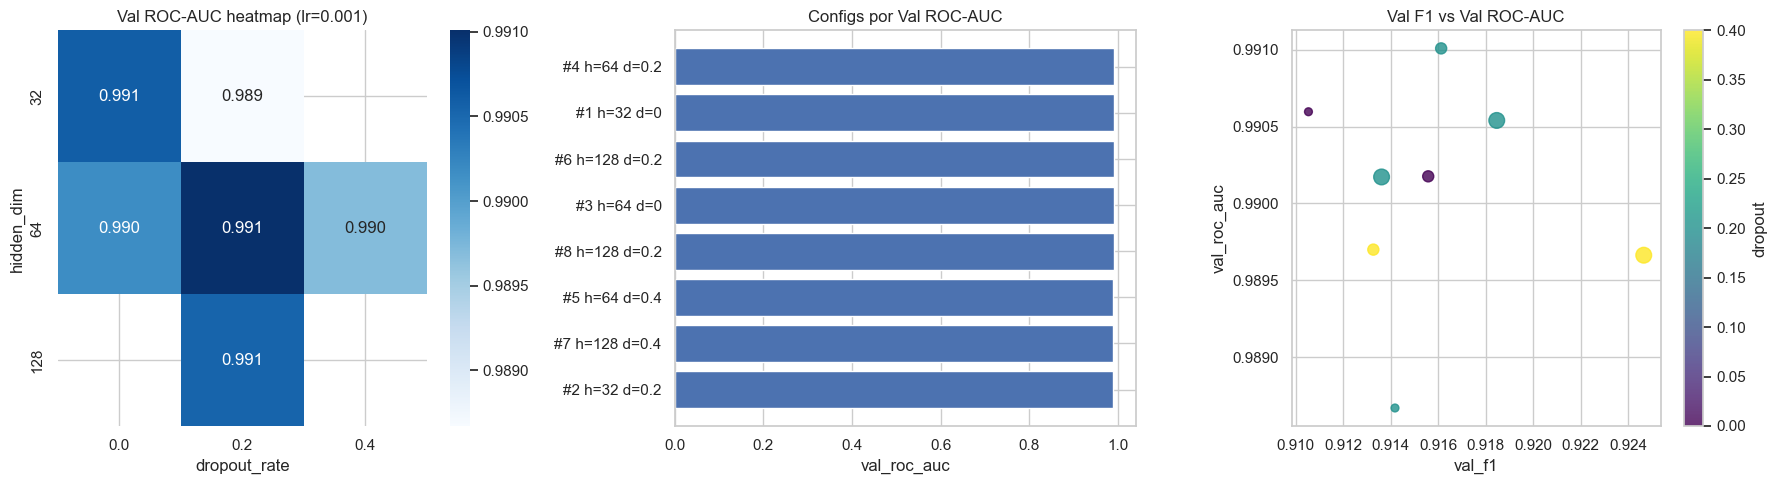

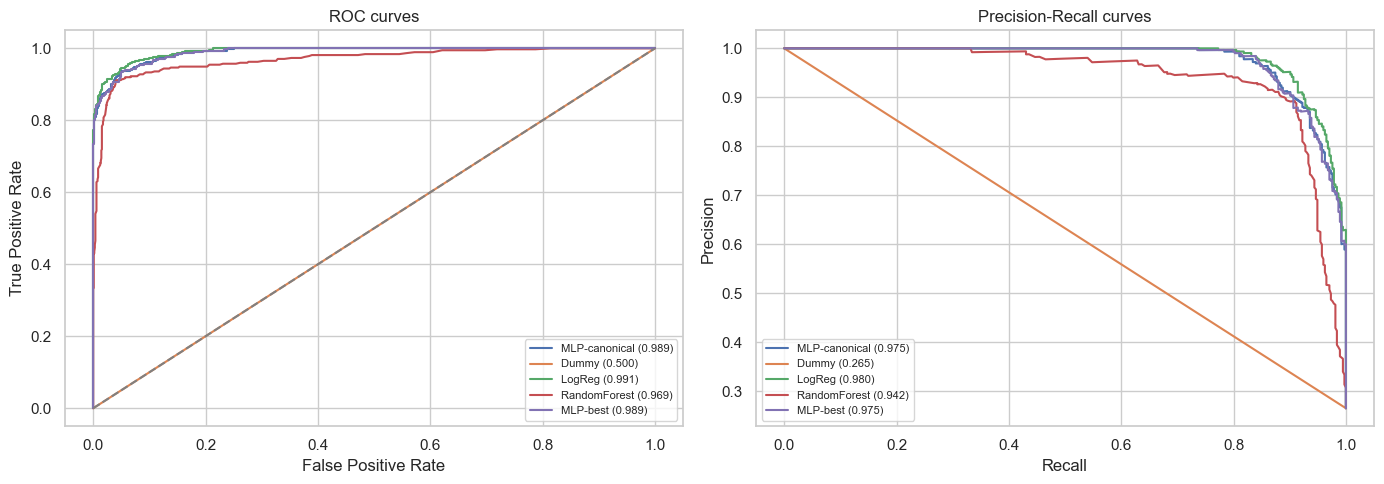

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogReg,0.9539,0.9055,0.9225,0.9139,0.9913,0.9803
1,MLP-canonical,0.9524,0.9398,0.8770,0.9073,0.9891,0.9754
2,MLP-best,0.9510,0.9446,0.8663,0.9038,0.9887,0.9747
3,RandomForest,0.9262,0.9470,0.7647,0.8462,0.9688,0.9423
4,Dummy,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654


In [61]:
def save_grid_plots(grid: pd.DataFrame, output_path: Path) -> Path:
    best_lr = grid.loc[grid["val_roc_auc"].idxmax(), "learning_rate"]
    grid_for_heatmap = grid[grid["learning_rate"] == best_lr]
    pivot = grid_for_heatmap.pivot_table(
        index="hidden_dim",
        columns="dropout_rate",
        values="val_roc_auc",
        aggfunc="max",
    )
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"Val ROC-AUC heatmap (lr={best_lr:g})")
    ordered = grid.sort_values("val_roc_auc", ascending=True)
    labels = ordered.apply(lambda row: f"#{int(row.config_id)} h={int(row.hidden_dim)} d={row.dropout_rate:g}", axis=1)
    axes[1].barh(labels, ordered["val_roc_auc"])
    axes[1].set_title("Configs por Val ROC-AUC")
    axes[1].set_xlabel("val_roc_auc")
    scatter = axes[2].scatter(
        grid["val_f1"],
        grid["val_roc_auc"],
        c=grid["dropout_rate"],
        s=grid["hidden_dim"],
        cmap="viridis",
        alpha=0.8,
    )
    axes[2].set_title("Val F1 vs Val ROC-AUC")
    axes[2].set_xlabel("val_f1")
    axes[2].set_ylabel("val_roc_auc")
    fig.colorbar(scatter, ax=axes[2], label="dropout")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return output_path


def save_overlay_roc_pr(probability_map: dict[str, np.ndarray], y_true: np.ndarray, output_path: Path) -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model_name, probabilities in probability_map.items():
        fpr, tpr, _ = roc_curve(y_true, probabilities)
        precision, recall, _ = precision_recall_curve(y_true, probabilities)
        axes[0].plot(fpr, tpr, label=f"{model_name} ({roc_auc_score(y_true, probabilities):.3f})")
        axes[1].plot(recall, precision, label=f"{model_name} ({average_precision_score(y_true, probabilities):.3f})")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title("ROC curves")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(fontsize=8)
    axes[1].set_title("Precision-Recall curves")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return output_path


comparison_df = pd.DataFrame(comparison_rows).drop_duplicates(subset=["model"], keep="last")
comparison_df = comparison_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)

grid_plot_path = save_grid_plots(grid_df, OUTPUT_DIR / "mlp_grid_plots.png")
overlay_path = save_overlay_roc_pr(model_probabilities, y_test_array, OUTPUT_DIR / "model_overlay_roc_pr.png")
comparison_path = OUTPUT_DIR / "comparison_df.csv"
grid_path = OUTPUT_DIR / "grid_df.csv"
comparison_df.to_csv(comparison_path, index=False)
grid_df.to_csv(grid_path, index=False)

with mlflow.start_run(run_name="comparison-summary"):
    for artifact in [grid_plot_path, overlay_path, comparison_path, grid_path, best_state_path]:
        mlflow.log_artifact(str(artifact), artifact_path="comparison")

comparison_df.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
})

## 11. Validação cruzada estratificada

Roda 5-fold apenas para MLP-best. As métricas de validação cruzada dos baselines sklearn permanecem no notebook 02, evitando novo treino de baseline na Etapa 2.

In [62]:
def summarize_cv(rows: list[dict[str, Any]]) -> pd.DataFrame:
    fold_df = pd.DataFrame(rows)
    summary = (
        fold_df.groupby("model")[["roc_auc", "pr_auc", "f1", "recall"]]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = ["_".join(col).strip("_") for col in summary.columns.to_flat_index()]
    return summary


def cross_validate_mlp(x: pd.DataFrame, y_values: pd.Series, splitter: StratifiedKFold, config: dict[str, Any]) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for fold, (train_idx, test_idx) in enumerate(splitter.split(x, y_values), start=1):
        set_seeds(RANDOM_SEED + 100 + fold)
        x_fold_train_full = x.iloc[train_idx]
        x_fold_test = x.iloc[test_idx]
        y_fold_train_full = y_values.iloc[train_idx]
        y_fold_test = y_values.iloc[test_idx]
        x_fold_train, x_fold_val, y_fold_train, y_fold_val = train_test_split(
            x_fold_train_full,
            y_fold_train_full,
            test_size=VAL_SIZE,
            stratify=y_fold_train_full,
            random_state=RANDOM_SEED + fold,
        )
        fold_preprocessor = build_preprocessor(x_fold_train)
        x_fold_train_tensor = as_float_tensor(fold_preprocessor.fit_transform(x_fold_train))
        y_fold_train_tensor = torch.tensor(y_fold_train.to_numpy(), dtype=torch.float32).view(-1, 1)
        x_fold_val_tensor = as_float_tensor(fold_preprocessor.transform(x_fold_val))
        y_fold_val_tensor = torch.tensor(y_fold_val.to_numpy(), dtype=torch.float32).view(-1, 1)
        x_fold_test_tensor = as_float_tensor(fold_preprocessor.transform(x_fold_test))
        generator = torch.Generator().manual_seed(RANDOM_SEED + fold)
        fold_train_loader = DataLoader(
            TensorDataset(x_fold_train_tensor, y_fold_train_tensor),
            batch_size=config["batch_size"],
            shuffle=True,
            generator=generator,
        )
        fold_val_loader = DataLoader(TensorDataset(x_fold_val_tensor, y_fold_val_tensor), batch_size=config["batch_size"], shuffle=False)
        fold_model = TelcoMLP(x_fold_train_tensor.shape[1], config["hidden_dim"], config["dropout_rate"])
        fold_optimizer = optim.Adam(fold_model.parameters(), lr=config["learning_rate"])
        fold_stopping = EarlyStopping(patience=6, min_delta=1e-4, mode="min")
        fit(
            model=fold_model,
            train_loader=fold_train_loader,
            val_loader=fold_val_loader,
            criterion=nn.BCEWithLogitsLoss(),
            optimizer=fold_optimizer,
            epochs=60,
            early_stopping=fold_stopping,
            monitor="val_loss",
            device=DEVICE,
        )
        probabilities = predict_mlp_probabilities(fold_model, x_fold_test_tensor)
        rows.append({"model": "MLP-best", "fold": fold, **evaluate_binary(y_fold_test, probabilities)})
    return rows


cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_rows = cross_validate_mlp(X, y, cv_splitter, best_grid_config)
cv_fold_df = pd.DataFrame(cv_rows)
cv_df = summarize_cv(cv_rows)
cv_path = OUTPUT_DIR / "cv_df.csv"
cv_fold_path = OUTPUT_DIR / "cv_fold_df.csv"
cv_df.to_csv(cv_path, index=False)
cv_fold_df.to_csv(cv_fold_path, index=False)
cv_df.style.format({col: "{:.4f}" for col in cv_df.columns if col != "model"})

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,MLP-best,0.9904,0.0022,0.9788,0.0044,0.9138,0.0159,0.8957,0.0345


## 12. Premissas de custo e threshold ótimo

Define custos parametrizados para falso positivo, falso negativo e verdadeiro positivo. Depois busca o threshold que minimiza custo esperado no test set.

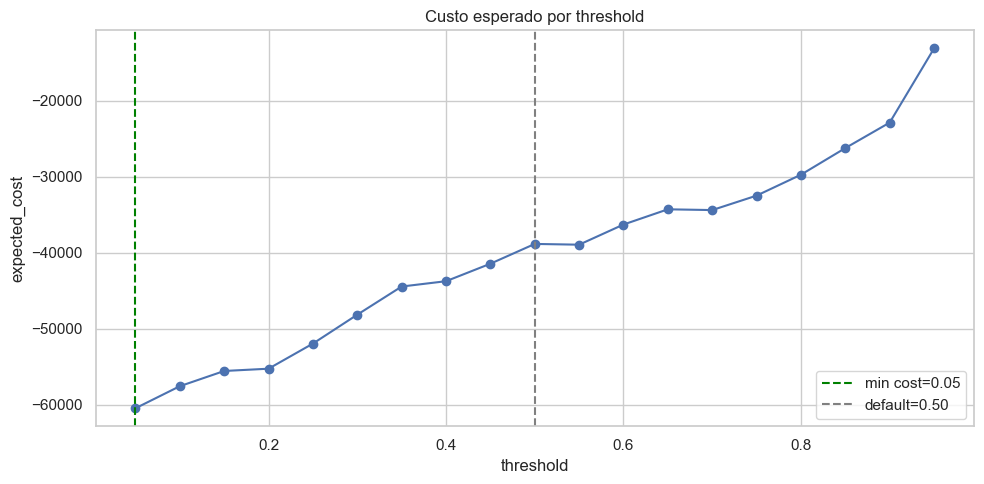

,actual,predicted,cell,cost
0,Stayed,Stayed,TN,0.0
1,Stayed,Churned,FP,50.0
2,Churned,Stayed,FN,500.0
3,Churned,Churned,TP,-200.0


,threshold,expected_cost,tn,fp,fn,tp
0,0.50,-38850.0,1016,19,50,324
1,0.05,-60450.0,916,119,12,362


In [63]:
COST_FP = 50.0
COST_FN = 500.0
COST_TP = -200.0
COST_TN = 0.0

cost_matrix_df = pd.DataFrame(
    [
        {"actual": "Stayed", "predicted": "Stayed", "cell": "TN", "cost": COST_TN},
        {"actual": "Stayed", "predicted": "Churned", "cell": "FP", "cost": COST_FP},
        {"actual": "Churned", "predicted": "Stayed", "cell": "FN", "cost": COST_FN},
        {"actual": "Churned", "predicted": "Churned", "cell": "TP", "cost": COST_TP},
    ]
)


def confusion_counts(y_true: np.ndarray, probabilities: np.ndarray, threshold: float) -> dict[str, int]:
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}


def expected_cost(counts: dict[str, int]) -> float:
    return COST_TN * counts["tn"] + COST_FP * counts["fp"] + COST_FN * counts["fn"] + COST_TP * counts["tp"]


thresholds = np.linspace(0.05, 0.95, 19)
cost_rows = []
for threshold in thresholds:
    counts = confusion_counts(y_test_array, mlp_best_probabilities, float(threshold))
    metric_row = evaluate_binary(y_test_array, mlp_best_probabilities, float(threshold))
    cost_rows.append({"threshold": float(threshold), **counts, "expected_cost": expected_cost(counts), **metric_row})

cost_df = pd.DataFrame(cost_rows)
best_cost_row = cost_df.loc[cost_df["expected_cost"].idxmin()].copy()
threshold_chosen = float(best_cost_row["threshold"])
default_counts = confusion_counts(y_test_array, mlp_best_probabilities, 0.5)
default_cost = expected_cost(default_counts)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cost_df["threshold"], cost_df["expected_cost"], marker="o")
ax.axvline(threshold_chosen, color="green", linestyle="--", label=f"min cost={threshold_chosen:.2f}")
ax.axvline(0.5, color="gray", linestyle="--", label="default=0.50")
ax.set_title("Custo esperado por threshold")
ax.set_xlabel("threshold")
ax.set_ylabel("expected_cost")
ax.legend()
fig.tight_layout()
cost_curve_path = OUTPUT_DIR / "cost_by_threshold.png"
fig.savefig(cost_curve_path, dpi=160, bbox_inches="tight")
plt.show()

display(cost_matrix_df)
pd.DataFrame(
    [
        {"threshold": 0.5, "expected_cost": default_cost, **default_counts},
        {"threshold": threshold_chosen, "expected_cost": best_cost_row["expected_cost"], **confusion_counts(y_test_array, mlp_best_probabilities, threshold_chosen)},
    ]
)

## 13. Trade-off, segmentos e calibração

Compara thresholds candidatos, calcula métricas por segmento e verifica calibração probabilística com Brier score.

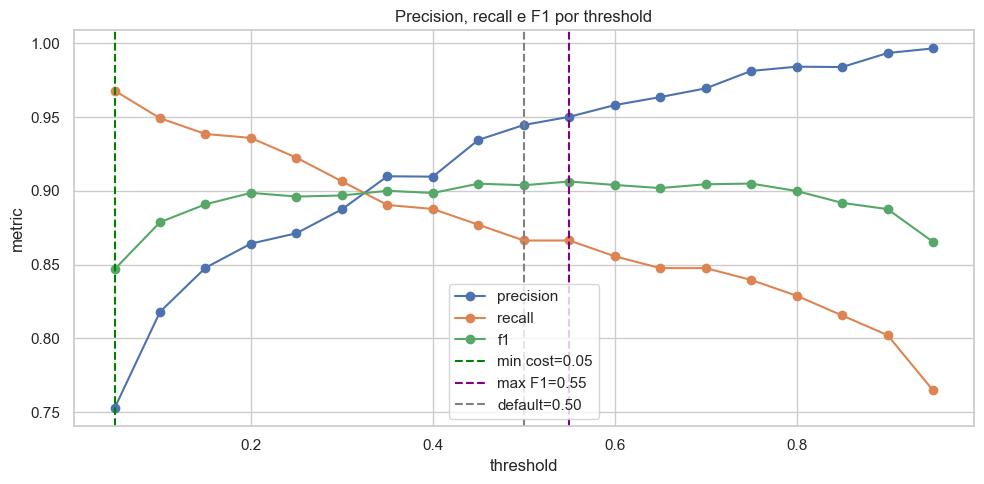

,candidate,threshold,tn,fp,fn,tp,expected_cost,accuracy,precision,recall,f1,roc_auc,pr_auc
0,default_0_5,0.5000,1016,19,50,324,-38850.00,0.9510,0.9446,0.8663,0.9038,0.9887,0.9747
1,max_f1,0.5500,1018,17,50,324,-38950.00,0.9524,0.9501,0.8663,0.9063,0.9887,0.9747
2,min_cost,0.0500,916,119,12,362,-60450.00,0.9070,0.7526,0.9679,0.8468,0.9887,0.9747
3,youden_j,0.2360,984,51,25,349,-54750.00,0.9461,0.8725,0.9332,0.9018,0.9887,0.9747


In [64]:
fpr_values, tpr_values, roc_thresholds = roc_curve(y_test_array, mlp_best_probabilities)
youden_index = int(np.argmax(tpr_values - fpr_values))
youden_threshold = float(roc_thresholds[youden_index])
f1_threshold = float(cost_df.loc[cost_df["f1"].idxmax(), "threshold"])

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["precision", "recall", "f1"]:
    ax.plot(cost_df["threshold"], cost_df[metric], marker="o", label=metric)
ax.axvline(threshold_chosen, color="green", linestyle="--", label=f"min cost={threshold_chosen:.2f}")
ax.axvline(f1_threshold, color="purple", linestyle="--", label=f"max F1={f1_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle="--", label="default=0.50")
ax.set_title("Precision, recall e F1 por threshold")
ax.set_xlabel("threshold")
ax.set_ylabel("metric")
ax.legend()
fig.tight_layout()
threshold_metrics_path = OUTPUT_DIR / "metrics_by_threshold.png"
fig.savefig(threshold_metrics_path, dpi=160, bbox_inches="tight")
plt.show()

candidate_thresholds = {
    "default_0_5": 0.5,
    "max_f1": f1_threshold,
    "min_cost": threshold_chosen,
    "youden_j": youden_threshold,
}
threshold_comparison_rows = []
for name, threshold in candidate_thresholds.items():
    counts = confusion_counts(y_test_array, mlp_best_probabilities, threshold)
    threshold_comparison_rows.append({
        "candidate": name,
        "threshold": threshold,
        **counts,
        "expected_cost": expected_cost(counts),
        **evaluate_binary(y_test_array, mlp_best_probabilities, threshold),
    })
threshold_comparison_df = pd.DataFrame(threshold_comparison_rows)
threshold_comparison_df.style.format({
    "threshold": "{:.4f}",
    "expected_cost": "{:.2f}",
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
})

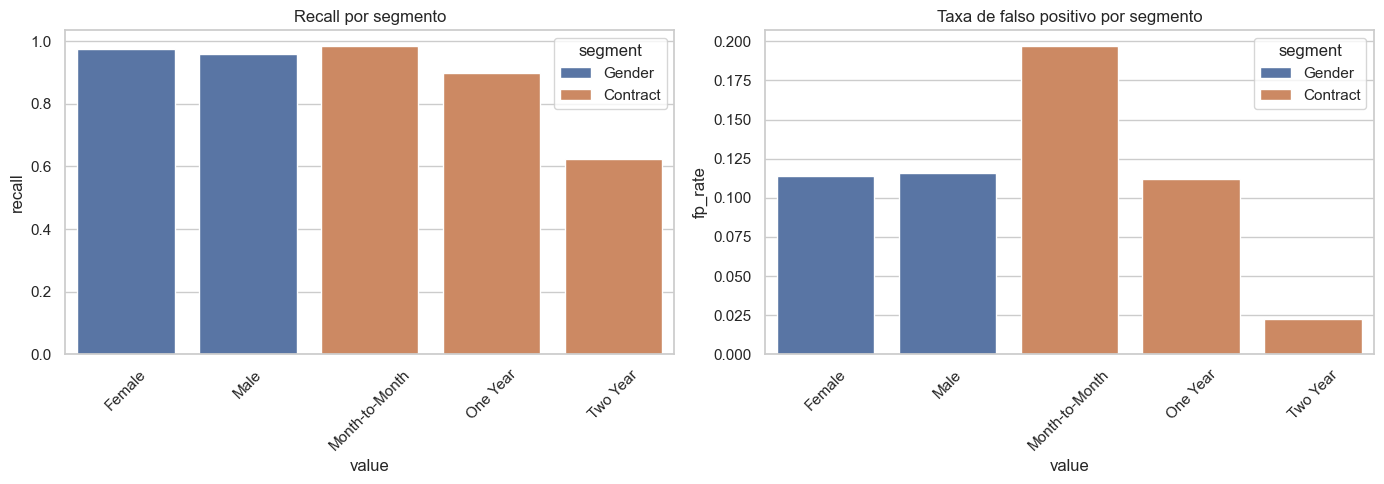

,segment,value,rows,churn_rate,recall,fp_rate,tn,fp,fn,tp
0,Gender,Female,720,28.19%,0.9754,0.1141,458,59,5,198
1,Gender,Male,689,24.82%,0.9591,0.1158,458,60,7,164
2,Contract,Month-to-Month,733,44.61%,0.9847,0.1970,326,80,5,322
3,Contract,One Year,315,12.38%,0.8974,0.1123,245,31,4,35
4,Contract,Two Year,361,2.22%,0.6250,0.0227,345,8,3,5


In [65]:
def segment_metric_rows(segment_frame: pd.DataFrame, segment_column: str) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for segment_value, group in segment_frame.groupby(segment_column, dropna=False):
        if len(group) == 0:
            continue
        counts = confusion_counts(group["y_true"].to_numpy(), group["probability"].to_numpy(), threshold_chosen)
        denominator_fp_rate = counts["fp"] + counts["tn"]
        rows.append({
            "segment": segment_column,
            "value": str(segment_value),
            "rows": len(group),
            "churn_rate": group["y_true"].mean(),
            "recall": recall_score(group["y_true"], group["prediction"], zero_division=0),
            "fp_rate": counts["fp"] / denominator_fp_rate if denominator_fp_rate else 0.0,
            **counts,
        })
    return rows


segment_frame = x_test_raw.copy()
segment_frame["y_true"] = y_test_array
segment_frame["probability"] = mlp_best_probabilities
segment_frame["prediction"] = (segment_frame["probability"] >= threshold_chosen).astype(int)

segment_rows: list[dict[str, Any]] = []
for segment_column in ["Gender", "Contract"]:
    if segment_column in segment_frame.columns:
        segment_rows.extend(segment_metric_rows(segment_frame, segment_column))

if "TenureMonths" in segment_frame.columns:
    segment_frame["TenureBucket"] = pd.cut(
        segment_frame["TenureMonths"],
        bins=[-np.inf, 12, 24, 48, 72, np.inf],
        labels=["0-12", "13-24", "25-48", "49-72", "73+"],
    )
    segment_rows.extend(segment_metric_rows(segment_frame, "TenureBucket"))

segments_df = pd.DataFrame(segment_rows)
segments_path = OUTPUT_DIR / "segments_df.csv"
segments_df.to_csv(segments_path, index=False)

if not segments_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=segments_df, x="value", y="recall", hue="segment", ax=axes[0])
    axes[0].set_title("Recall por segmento")
    axes[0].tick_params(axis="x", rotation=45)
    sns.barplot(data=segments_df, x="value", y="fp_rate", hue="segment", ax=axes[1])
    axes[1].set_title("Taxa de falso positivo por segmento")
    axes[1].tick_params(axis="x", rotation=45)
    fig.tight_layout()
    segment_plot_path = OUTPUT_DIR / "segment_metrics.png"
    fig.savefig(segment_plot_path, dpi=160, bbox_inches="tight")
    plt.show()
else:
    segment_plot_path = None
    print("Nenhuma coluna de segmento esperada foi encontrada.")

segments_df.style.format({"churn_rate": "{:.2%}", "recall": "{:.4f}", "fp_rate": "{:.4f}"})

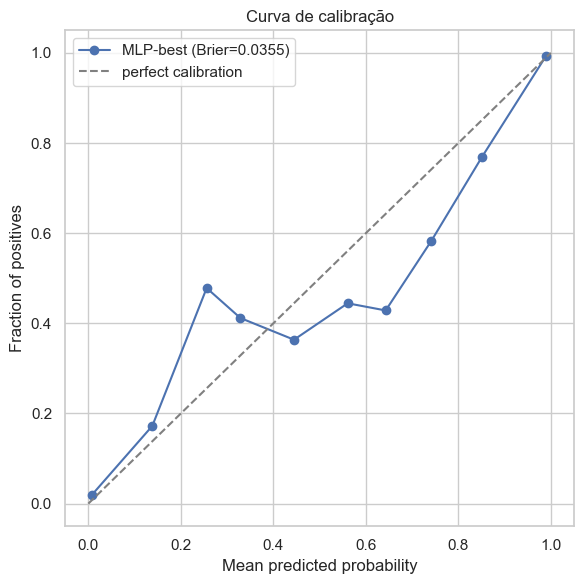

brier_score=0.0355
Calibração aceitável para priorização operacional inicial. Se o threshold virar política de negócio sensível a orçamento, testar calibração sigmoid/isotonic na Etapa 3.


In [66]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test_array,
    mlp_best_probabilities,
    n_bins=10,
    strategy="uniform",
)
brier = float(brier_score_loss(y_test_array, mlp_best_probabilities))

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_predicted_value, fraction_of_positives, marker="o", label=f"MLP-best (Brier={brier:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
ax.set_title("Curva de calibração")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend()
fig.tight_layout()
calibration_path = OUTPUT_DIR / "calibration_curve.png"
fig.savefig(calibration_path, dpi=160, bbox_inches="tight")
plt.show()

calibration_note = (
    "Calibração aceitável para priorização operacional inicial. "
    "Se o threshold virar política de negócio sensível a orçamento, testar calibração sigmoid/isotonic na Etapa 3."
)
print(f"brier_score={brier:.4f}")
print(calibration_note)

## 14. Registro final no MLflow

Registra o MLP vencedor com threshold escolhido, premissas de custo, métricas finais e artefatos de avaliação.

In [67]:
final_metrics = evaluate_binary(y_test_array, mlp_best_probabilities, threshold=threshold_chosen)
final_counts = confusion_counts(y_test_array, mlp_best_probabilities, threshold_chosen)
final_expected_cost = expected_cost(final_counts)

threshold_comparison_path = OUTPUT_DIR / "threshold_comparison_df.csv"
cost_df_path = OUTPUT_DIR / "cost_df.csv"
threshold_comparison_df.to_csv(threshold_comparison_path, index=False)
cost_df.to_csv(cost_df_path, index=False)

final_checkpoint_path = OUTPUT_DIR / "mlp_final_checkpoint.pt"
torch.save(
    {
        "config": best_grid_config,
        "state_dict": mlp_best.state_dict(),
        "input_dim": INPUT_DIM,
        "threshold": threshold_chosen,
        "feature_names": feature_names,
        "costs": {"cost_fp": COST_FP, "cost_fn": COST_FN, "cost_tp": COST_TP, "cost_tn": COST_TN},
    },
    final_checkpoint_path,
)

artifact_paths = [
    comparison_path,
    grid_path,
    cv_path,
    cv_fold_path,
    cost_df_path,
    threshold_comparison_path,
    segments_path,
    cost_curve_path,
    threshold_metrics_path,
    calibration_path,
    final_checkpoint_path,
]
if segment_plot_path is not None:
    artifact_paths.append(segment_plot_path)

with mlflow.start_run(run_name="mlp-final") as final_run:
    mlflow.set_tag("dataset.mlflow_run_id", DATASET_SOURCE_RUN_ID)
    mlflow.log_params({
        **best_grid_config,
        "input_dim": INPUT_DIM,
        "threshold_chosen": threshold_chosen,
        "threshold_policy": "min_expected_cost",
        "cost_fp": COST_FP,
        "cost_fn": COST_FN,
        "cost_tp": COST_TP,
        "cost_tn": COST_TN,
        "random_seed": RANDOM_SEED,
    })
    mlflow.log_metrics({
        **{f"test_{key}": value for key, value in finite_metrics(final_metrics).items()},
        **{f"count_{key}": float(value) for key, value in final_counts.items()},
        "expected_cost": float(final_expected_cost),
        "brier_score": brier,
    })
    for artifact_path in artifact_paths:
        mlflow.log_artifact(str(artifact_path), artifact_path="final")

    input_example = x_test_tensor[:5].numpy()
    output_example = mlp_best_probabilities[:5]
    signature = infer_signature(input_example, output_example)
    model_info = mlflow.pytorch.log_model(
        pytorch_model=mlp_best,
        name="model",
        input_example=input_example,
        signature=signature,
    )
    final_run_id = final_run.info.run_id

disable_logging()
try:
    registered_model = mlflow.register_model(model_info.model_uri, "Telco-Churn-MLP")
    print(f"registered_model={registered_model.name} version={registered_model.version}")
except Exception as exc:
    print(f"Registro no Model Registry ignorado: {exc}")
finally:
    enable_logging()

print(f"final_run_id={final_run_id}")
print(f"threshold_chosen={threshold_chosen:.4f}")
print(f"expected_cost={final_expected_cost:.2f}")

registered_model=Telco-Churn-MLP version=2
final_run_id=6119b65faf1c4e4f9fbd7c09c0ddcf33
threshold_chosen=0.0500
expected_cost=-60450.00


,run_id,run_name,holdout_pr_auc,extended_best_pr_auc
0,8ad3be23ec604923be8caaf14f304486,etapa1-extended-analysis,NaN,0.980285
1,37a49f35e7bd4237a83a1e7316fbada5,etapa1-random_forest,0.942268,NaN
2,a9050555d11945e2b9fc14dcbbe5bfad,etapa1-logistic_regression,0.980285,NaN
3,cfa366784da4428e9f68ed90490cbdba,etapa1-dummy_classifier,0.265436,NaN
4,e25c66262cf440a2ad9208757c89ca29,etapa1-random_forest,0.942268,NaN
5,958e9feb984f48c4bd7356ae8f7a5efc,etapa1-logistic_regression,0.980285,NaN
6,6650b449511447058b673f4913408a8b,etapa1-dummy_classifier,0.265436,NaN
7,2331fdf655ae49d0864f2ad7fe4ff568,etapa1-hist_gradient_boosting,0.983598,NaN
8,49918091425a4470b25fe0e767f9336a,etapa1-random_forest,0.942268,NaN
9,729e5a90f7214d61a773ef8de234bf4a,etapa1-logistic_regression,0.980285,NaN


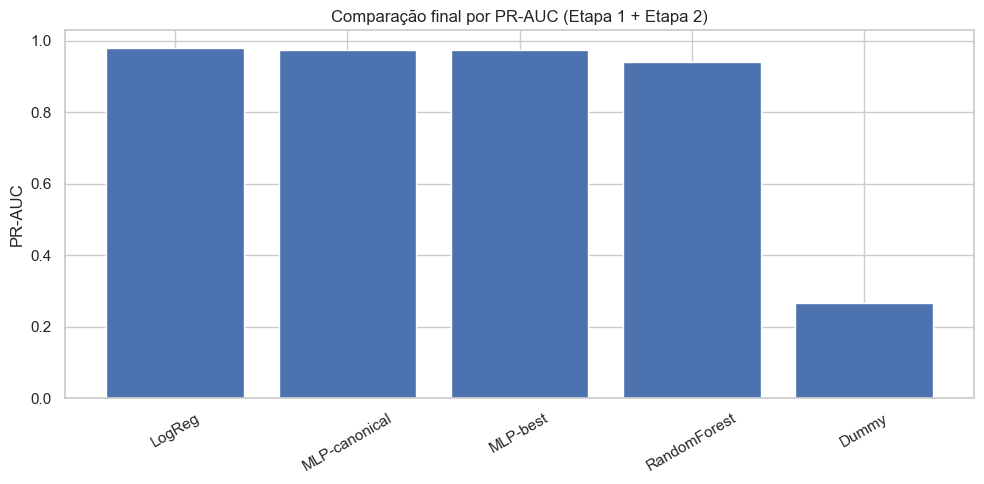

In [68]:
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
experiment_baselines = client.get_experiment_by_name("telco-churn-etapa-1-baselines")

recent_baseline_runs = []
if experiment_baselines is not None:
    runs = client.search_runs(
        experiment_ids=[experiment_baselines.experiment_id],
        order_by=["attributes.start_time DESC"],
        max_results=10,
    )
    for run in runs:
        recent_baseline_runs.append(
            {
                "run_id": run.info.run_id,
                "run_name": run.data.tags.get("mlflow.runName", ""),
                "holdout_pr_auc": run.data.metrics.get("holdout_pr_auc"),
                "extended_best_pr_auc": run.data.metrics.get("extended_best_pr_auc"),
            }
        )

recent_baseline_runs_df = pd.DataFrame(recent_baseline_runs)
display(recent_baseline_runs_df)

fig_compare_stage, ax = plt.subplots(figsize=(10, 5))
plot_df = comparison_df.sort_values("pr_auc", ascending=False)
ax.bar(plot_df["model"], plot_df["pr_auc"])
ax.set_title("Comparação final por PR-AUC (Etapa 1 + Etapa 2)")
ax.set_ylabel("PR-AUC")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

with mlflow.start_run(run_name="comparison-pr-auc-figure"):
    mlflow.log_figure(fig_compare_stage, "comparison/pr_auc_comparison_bar.png")

plt.show()

## Conclusão

Consolida os modelos avaliados. O modelo final é o `MLP-best`, escolhido pelo melhor `val_roc_auc` no grid e calibrado operacionalmente pelo threshold de menor custo esperado.

In [69]:
summary_df = comparison_df.copy()
summary_df["rank_roc_auc"] = summary_df["roc_auc"].rank(ascending=False, method="min").astype(int)
summary_df = summary_df.sort_values(["rank_roc_auc", "model"])

n_customers_month = 10_000
churn_actions_rate = (mlp_best_probabilities >= threshold_chosen).mean()
expected_monthly_cost = final_expected_cost * (n_customers_month / len(y_test_array))
default_monthly_cost = default_cost * (n_customers_month / len(y_test_array))
estimated_monthly_savings = default_monthly_cost - expected_monthly_cost

executive_summary = pd.DataFrame(
    [
        {"item": "modelo_final", "value": "MLP-best"},
        {"item": "threshold_escolhido", "value": f"{threshold_chosen:.4f}"},
        {"item": "criterio_threshold", "value": "menor custo esperado"},
        {"item": "taxa_clientes_priorizados", "value": f"{churn_actions_rate:.2%}"},
        {"item": "custo_estimado_mensal_10k_clientes", "value": f"R$ {expected_monthly_cost:,.2f}"},
        {"item": "economia_vs_threshold_0_5_10k_clientes", "value": f"R$ {estimated_monthly_savings:,.2f}"},
        {"item": "limitacoes", "value": "sem dinâmica temporal; premissas de custo simuladas; calibração deve ser revisitada antes de produção"},
    ]
)

summary_path = OUTPUT_DIR / "executive_summary.csv"
summary_df_path = OUTPUT_DIR / "summary_comparison_df.csv"
executive_summary.to_csv(summary_path, index=False)
summary_df.to_csv(summary_df_path, index=False)

display(executive_summary)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
}))
display(cv_df.style.format({col: "{:.4f}" for col in cv_df.columns if col != "model"}))

,item,value
0,modelo_final,MLP-best
1,threshold_escolhido,0.0500
2,criterio_threshold,menor custo esperado
3,taxa_clientes_priorizados,34.14%
4,custo_estimado_mensal_10k_clientes,"R$ -429,027.68"
5,economia_vs_threshold_0_5_10k_clientes,"R$ 153,300.21"
6,limitacoes,sem dinâmica temporal; premissas de custo simu...


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,rank_roc_auc
0,LogReg,0.9539,0.9055,0.9225,0.9139,0.9913,0.9803,1
1,MLP-canonical,0.9524,0.9398,0.8770,0.9073,0.9891,0.9754,2
2,MLP-best,0.9510,0.9446,0.8663,0.9038,0.9887,0.9747,3
3,RandomForest,0.9262,0.9470,0.7647,0.8462,0.9688,0.9423,4
4,Dummy,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654,5


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,MLP-best,0.9904,0.0022,0.9788,0.0044,0.9138,0.0159,0.8957,0.0345
